In [1]:
# !python -m pip install lightning

import numpy as np
import pandas as pd

import os

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from pathlib import Path


from torchvision import datasets, transforms
from torchvision.transforms import v2


import pytorch_lightning as pl
from pytorch_lightning import Trainer, callbacks, loggers
from torch.optim.lr_scheduler import ReduceLROnPlateau, StepLR
import datetime


print(os.getcwd())

C:\Users\flash\Desktop\Jobvorbereitungen\Projekte\DataScience\ImageClassification


In [2]:
import logging
import smtplib
import os
os.makedirs("Logs", exist_ok= True)
use_mail = False

logger = logging.getLogger(__name__)
logger.setLevel(logging.INFO)

formatter = logging.Formatter('%(name)s : %(levelname)s:%(levelno)s  %(asctime)s    %(message)s ')

info_handler = logging.FileHandler('Logs/Advanced_Logging_INFO_Level.log')
info_handler.setLevel(logging.INFO)
info_handler.setFormatter(formatter)
logger.addHandler(info_handler)



if use_mail:
    from email_logger_config import email_info
    login = "your@gmail.com"
    pswd = "**** **** **** ****" # Configured over gmail app-password
    email_info_example = {
    "mailhost": ('smtp.gmail.com', 587), # Everywhere on teh internet it recommended port 465, but what ended working was port 587
    "fromaddr": ["your@gmail.com"],
    "toaddrs": ["your@gmail.com"],
    "subject": 'Script Error Message',
    "credentials": (login, pswd),
    "secure": (),
    "timeout": 15.0 # time-out  default is 1 second, which leads to a time-out error
    }

    error_emailer = logging.handlers.SMTPHandler(**email_info)

    error_emailer.setLevel(logging.ERROR)
    logger.addHandler(error_emailer)
else:
    error_handler = logging.FileHandler('Logs/Advanced_Logging_ERROR_Level.log')
    error_handler.setLevel(logging.ERROR)
    error_handler.setFormatter(formatter)
    logger.addHandler(error_handler)

# Hypothetical


logger.info("Loggers created")

In [3]:
if torch.cuda.is_available():
    device = torch.device("cuda")
    accelerator = "gpu"
    from google.colab import drive
    drive.mount('/content/drive')
    root_dir = "./drive/MyDrive/Colab Data/ResidualNeuralNetwork"
    torch.cuda.memory.empty_cache()
else:
    device = torch.device("cpu")
    accelerator = "cpu"
    root_dir = "."

In [4]:
!set "PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True"

In [5]:
class ImageFolderCustom(Dataset):
    def __init__(self, targ_dir, transform=None):
        self.dirs = os.listdir(targ_dir) # each folder represents one class and contains the images of that class
        self.paths = []
        self.classes = []
        for i, Dir in enumerate(self.dirs):
            paths = list(Path(f"{targ_dir}/{Dir}").glob("*.jpg"))
            self.paths.extend(paths)
            self.classes.extend([i] * len(paths))
        self.transform = transform
        self.cache = {}
        
    def load_image(self, index):
        image_path = self.paths[index]
        return Image.open(image_path)

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, index):
        if not (index in self.cache):
            img = self.load_image(index)
            class_idx = self.classes[index]
            self.cache[index] = (img, class_idx)
        else:
            img, class_idx = self.cache[index]

        if self.transform:
            return self.transform(img), class_idx
        else:
            return img, class_idx

In [6]:
class Basic_Hyperparameters:
    epochs = 30
    lr = 1e-5
    l2 = 1e-4
    lr_decay_gamma = 0.1
    lr_decay_stepsize = 2
    lr_decay_threshold = 1e-3
    num_classes = 2
    earlystop_vallos = 1e-4
    earlystop_patience = 10
    gradient_clip_val = 1.0
    batch_size = 75
    latent_dim = 1000


hp = Basic_Hyperparameters()

In [7]:
from tqdm import tqdm

# prepare the Data and DataAugmentation
batch_size = hp.batch_size
height = 128
width = 128
classes = hp.num_classes
shuffle = True
valid_size = 0.1
pin_memory = True if torch.cuda.is_available() else False
num_workers = 0
persistent_workers = False
##### Detemine mean and std for each channel ##########################################
Basic_Augmentation_Pipeline = v2.Compose([
    v2.ToImage(), v2.ToDtype(torch.float32, scale=True), # v2.ToTensor() is apparently depricatd and this new line is the replacement
    v2.Resize((width, height))])

train_val_dataset_prep = ImageFolderCustom(f"{root_dir}/Data/Cats_Dogs/train", transform = Basic_Augmentation_Pipeline) # datasets.ImageFolder

num_train = len(train_val_dataset_prep)
indices = list(range(num_train))
split = int(np.floor(valid_size * num_train))

if shuffle:
    np.random.seed(79)
    np.random.shuffle(indices)

train_idx, valid_idx = indices[split:], indices[:split]
train_sampler = torch.utils.data.sampler.SubsetRandomSampler(train_idx)
valid_sampler = torch.utils.data.sampler.SubsetRandomSampler(valid_idx)


train_loader = DataLoader(train_val_dataset_prep, batch_size=batch_size, sampler=train_sampler)
batches = 0
means = torch.tensor([0.0, 0.0, 0.0])
stds = torch.tensor([0.0, 0.0, 0.0])
for img, labels in tqdm(train_loader, desc = "Computing mean and std of the initial 3 channels"):
    batches += 1
    img = img.view(img.shape[1], -1) # (3, batch_size*width*height)
    batch_means = img.mean(dim = 1) # (3,)
    batch_stds = img.std(dim = 1) # (3,)
    means += batch_means
    stds += batch_stds

means /= batches
stds /= batches

Image_augmentation_pipeline = v2.Compose([
    v2.ToImage(), v2.ToDtype(torch.float32, scale=True), # v2.ToTensor() is apparently depricatd and this new line is the replacement
    v2.RandomHorizontalFlip(p = 0.5),
    v2.RandomVerticalFlip(p= 0.5),
    v2.ColorJitter(brightness = 0.3, contrast = 0.3, saturation = 0.3),
    v2.Resize((width, height)),
    v2.Normalize(means, stds)
])

Validation_augmentation_pipeline = Image_augmentation_pipeline = v2.Compose([
    v2.ToImage(), v2.ToDtype(torch.float32, scale=True), # v2.ToTensor() is apparently depricatd and this new line is the replacement
    v2.Resize((width, height)),
    v2.Normalize(means, stds)
])

train_dataset = ImageFolderCustom(f"{root_dir}/Data/Cats_Dogs/train", transform = Image_augmentation_pipeline) # datasets.ImageFolder
train_loader = DataLoader(train_dataset, batch_size=hp.batch_size, sampler=train_sampler, num_workers = num_workers, pin_memory = pin_memory, persistent_workers = persistent_workers)
val_dataset = ImageFolderCustom(f"{root_dir}/Data/Cats_Dogs/train", transform = Validation_augmentation_pipeline)
val_loader = DataLoader(val_dataset, batch_size=hp.batch_size, sampler=valid_sampler, num_workers = num_workers, pin_memory = pin_memory, persistent_workers = persistent_workers)

# Currently the labels are indices range(0, classes). In the pytorch lightnign class, the labels will be one-hot encoded before training
# In Integers: 0 is Cat, 1 is Dog.
# In OneHot: [1, 0] is Cat, [0, 1] is Dog.

Computing mean and std of the initial 3 channels: 100%|██████████| 300/300 [01:23<00:00,  3.61it/s]


In [8]:
# Start TensorBoard server once trainign has started over the anaconda prompter
###### tensorboard --logdir=Checkpoints

# Open browser to http://localhost:6006
# View real-time loss curves, histograms, and model graphs

# Prepare the Model

In [9]:
repo = "pytorch/vision"
model = "mobilenet_v3_large"
weights = "MobileNet_V3_Large_Weights.IMAGENET1K_V1" # the default and only option

pretrained_convnet = torch.hub.load(
    repo_or_dir = repo, 
    model = model,
    weights = weights    
)

# pretrained_resnet.eval()

Using cache found in C:\Users\flash/.cache\torch\hub\pytorch_vision_main


In [10]:
for name, layer in pretrained_convnet.named_children():
    print(name + ":", end = " ")
    if name in ["features", "avgpool"]:
        print("Frozen")
        for param in layer.parameters():
            param.requires_grad = False
    else:
        print("Not Frozen")

features: Frozen
avgpool: Frozen
classifier: Not Frozen


In [11]:
class Linear_Expansion(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.fc1 = nn.Linear(1000, 500)
        self.fc2 = nn.Linear(500, 2)
        
        self.fcbn0 = nn.BatchNorm1d(1000)
        self.fcbn1 = nn.BatchNorm1d(500)

        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.3)

    def forward(self, x):
        x = self.dropout(self.relu(self.fcbn0(x))) # the first x is the output from the pretrained resnet
        x = self.dropout(self.relu(self.fcbn1(self.fc1(x))))
        x = self.fc2(x)
        return x        

In [12]:
class Image_Lightning(pl.LightningModule):
    def __init__(self, hp):
        super().__init__()
        self.hp = hp
        self.base = pretrained_convnet
        self.linear_expansion = Linear_Expansion()
        self.criterion = nn.CrossEntropyLoss()
        
    def _forward(self, x):
        x = self.base(x)
        x = self.linear_expansion(x)
        return x


    def configure_optimizers(self):
        # "weigth decay" is L2 Regularizer
        optimizer = torch.optim.AdamW(self.parameters(), lr= self.hp.lr, weight_decay = self.hp.l2)
        scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=hp.lr_decay_gamma, patience=hp.lr_decay_stepsize, threshold = hp.lr_decay_threshold)
        return  {"optimizer": optimizer, "lr_scheduler": scheduler, "monitor": "train_loss"}
            

    def training_step(self, batch, batch_idx):
        x, y = batch
        y_pred = self._forward(x)
        loss = self.criterion(y_pred, y)
        acc = np.mean(torch.argmax(y_pred.detach(), axis = 1).flatten().numpy() == y.flatten().numpy())
        self.log("train_loss", loss)
        self.log("train_acc", acc)
        return loss

    def validation_step(self, batch, batch_idx):
        x, y = batch
        y_pred = self._forward(x)
        acc = np.mean(torch.argmax(y_pred.detach(), axis = 1).flatten().numpy() == y.flatten().numpy())
        loss = self.criterion(y_pred, y)
        self.log("val_loss", loss)
        self.log("val_acc", acc)

    def forward(self, x):
        y_pred = self._forward(x)
        return y_pred

In [13]:
from pytorch_lightning import Trainer, callbacks, loggers

from torch import nn
from pathlib import Path

import os
# The Callbacks

modelname = "ConvNet_Classif"

earlyStop = callbacks.EarlyStopping(monitor = 'val_loss',
                                    patience = hp.earlystop_patience,
                                    min_delta = hp.earlystop_vallos)

checkPointTraining = callbacks.ModelCheckpoint(dirpath = f"Checkpoints/{modelname}",
                                                filename = "{epoch}",
                                                monitor='val_loss',
                                                verbose=0,
                                                save_top_k = -1,
                                                save_weights_only=False)

csv_logger = loggers.CSVLogger(save_dir = "Logs", name = modelname)

# The Trainer
trainer = Trainer(callbacks=[earlyStop, checkPointTraining],
                  logger = csv_logger,
                  max_epochs = hp.epochs,
                  log_every_n_steps=1,
                  accelerator = accelerator,
                  devices = 1,
                  precision = "16-mixed",
                  gradient_clip_val = hp.gradient_clip_val
                 )

C:\Users\flash\anaconda3\envs\ML_Pytorch\Lib\site-packages\pytorch_lightning\trainer\connectors\accelerator_connector.py:479: You passed `Trainer(accelerator='cpu', precision='16-mixed')` but AMP with fp16 is not supported on CPU. Using `precision='bf16-mixed'` instead.
Using bfloat16 Automatic Mixed Precision (AMP)
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


In [14]:
# The Model
# Check if Training from scratch or resume training from checkpoint
os.makedirs(f"Checkpoints/{modelname}", exist_ok = True)
checkpoints = [i for i in os.listdir(f"Checkpoints/{modelname}")]
if ".training_done" in checkpoints:
    print("Model has already been fully trained.")
else:
    try:
        checkpoints = [i for i in checkpoints if i.endswith(".ckpt")]
        starting_epoch = np.max([int(i.replace(".ckpt", "").replace("epoch=", "")) for i in checkpoints])
        last_checkpoint_filepath = f"Checkpoints/{modelname}/epoch={starting_epoch}.ckpt"

        Model = Image_Lightning.load_from_checkpoint(last_checkpoint_filepath, hp = hp)
        trainer.fit(model = Model, train_dataloaders = train_loader, val_dataloaders = val_loader, ckpt_path = last_checkpoint_filepath)

    except Exception as e:
        print(e)
        Model = Image_Lightning(hp = hp)
        trainer.fit(model = Model, train_dataloaders = train_loader, val_dataloaders = val_loader)

    
    Path(f"Checkpoints/{modelname}/.training_done").touch()

zero-size array to reduction operation maximum which has no identity


C:\Users\flash\anaconda3\envs\ML_Pytorch\Lib\site-packages\pytorch_lightning\utilities\model_summary\model_summary.py:242: Precision bf16-mixed is not supported by the model summary.  Estimated model size in MB will not be accurate. Using 32 bits instead.


┏━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name             ┃ Type             ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ base             │ MobileNetV3      │  5.5 M │ train │     0 │
│ 1 │ linear_expansion │ Linear_Expansion │  504 K │ train │     0 │
│ 2 │ criterion        │ CrossEntropyLoss │      0 │ train │     0 │
└───┴──────────────────┴──────────────────┴────────┴───────┴───────┘

Trainable params: 3.0 M                                                                                            
Non-trainable params: 3.0 M                                                                                        
Total params: 6.0 M                                                                                                
Total estimated model params size (MB): 23.950                                                                     
Modules in train mode: 263                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

...

C:\Users\flash\anaconda3\envs\ML_Pytorch\Lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:4
34: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the
`num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.

C:\Users\flash\anaconda3\envs\ML_Pytorch\Lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:4
34: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of 
the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.


Detected KeyboardInterrupt, attempting graceful shutdown ...


SystemExit: 1

C:\Users\flash\anaconda3\envs\ML_Pytorch\Lib\site-packages\IPython\core\interactiveshell.py:3756: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


In [16]:
import os
import shutil
os.makedirs(f"Models/{modelname}", exist_ok = True)
if "BestModel.save" not in os.listdir(f"Models/{modelname}"):
    Model = Image_Lightning.load_from_checkpoint(checkPointTraining.best_model_path, hp = hp)
    saving_Trainer = Trainer(max_epochs = 0)
    saving_Trainer.fit(Model, train_dataloaders = train_loader, val_dataloaders = val_loader)
    saving_Trainer.save_checkpoint(f"Models/{modelname}/BestModel.save", weights_only = True)
ConvNet = Image_Lightning.load_from_checkpoint(f"Models/{modelname}/BestModel.save", hp = hp)
ConvNet.eval()

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


┏━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name             ┃ Type             ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ base             │ MobileNetV3      │  5.5 M │ train │     0 │
│ 1 │ linear_expansion │ Linear_Expansion │  504 K │ train │     0 │
│ 2 │ criterion        │ CrossEntropyLoss │      0 │ train │     0 │
└───┴──────────────────┴──────────────────┴────────┴───────┴───────┘

Trainable params: 3.0 M                                                                                            
Non-trainable params: 3.0 M                                                                                        
Total params: 6.0 M                                                                                                
Total estimated model params size (MB): 23.950                                                                     
Modules in train mode: 263                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

`Trainer.fit` stopped: `max_epochs=0` reached.


Image_Lightning(
  (base): MobileNetV3(
    (features): Sequential(
      (0): Conv2dNormActivation(
        (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
        (2): Hardswish()
      )
      (1): InvertedResidual(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=16, bias=False)
            (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
            (2): ReLU(inplace=True)
          )
          (1): Conv2dNormActivation(
            (0): Conv2d(16, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
            (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
          )
        )
      )
      (2): InvertedResidual(
        (block): Sequential(
          (0): Conv2dNormActivati

In [17]:
import glob
from PIL import Image

class TestDataset(torch.utils.data.Dataset):
    def __init__(self, path, transform=None):
        self.image_paths = glob.glob(path + '*.jpg')
        self.transform = transform

    def __getitem__(self, index):
        x = Image.open(self.image_paths[index])
        if self.transform is not None:
            x = self.transform(x)

        return x

    def __len__(self):
        return len(self.image_paths)

test_dataset = TestDataset(f"Data/Cats_Dogs/test1/", transform = Validation_augmentation_pipeline)
test_loader = torch.utils.data.DataLoader(test_dataset, shuffle = True)

C:\Users\flash\AppData\Local\Temp\ipykernel_8088\3257707325.py:14: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  ax.imshow(np.minimum(image_for_plotting*stds + means, 1.0))


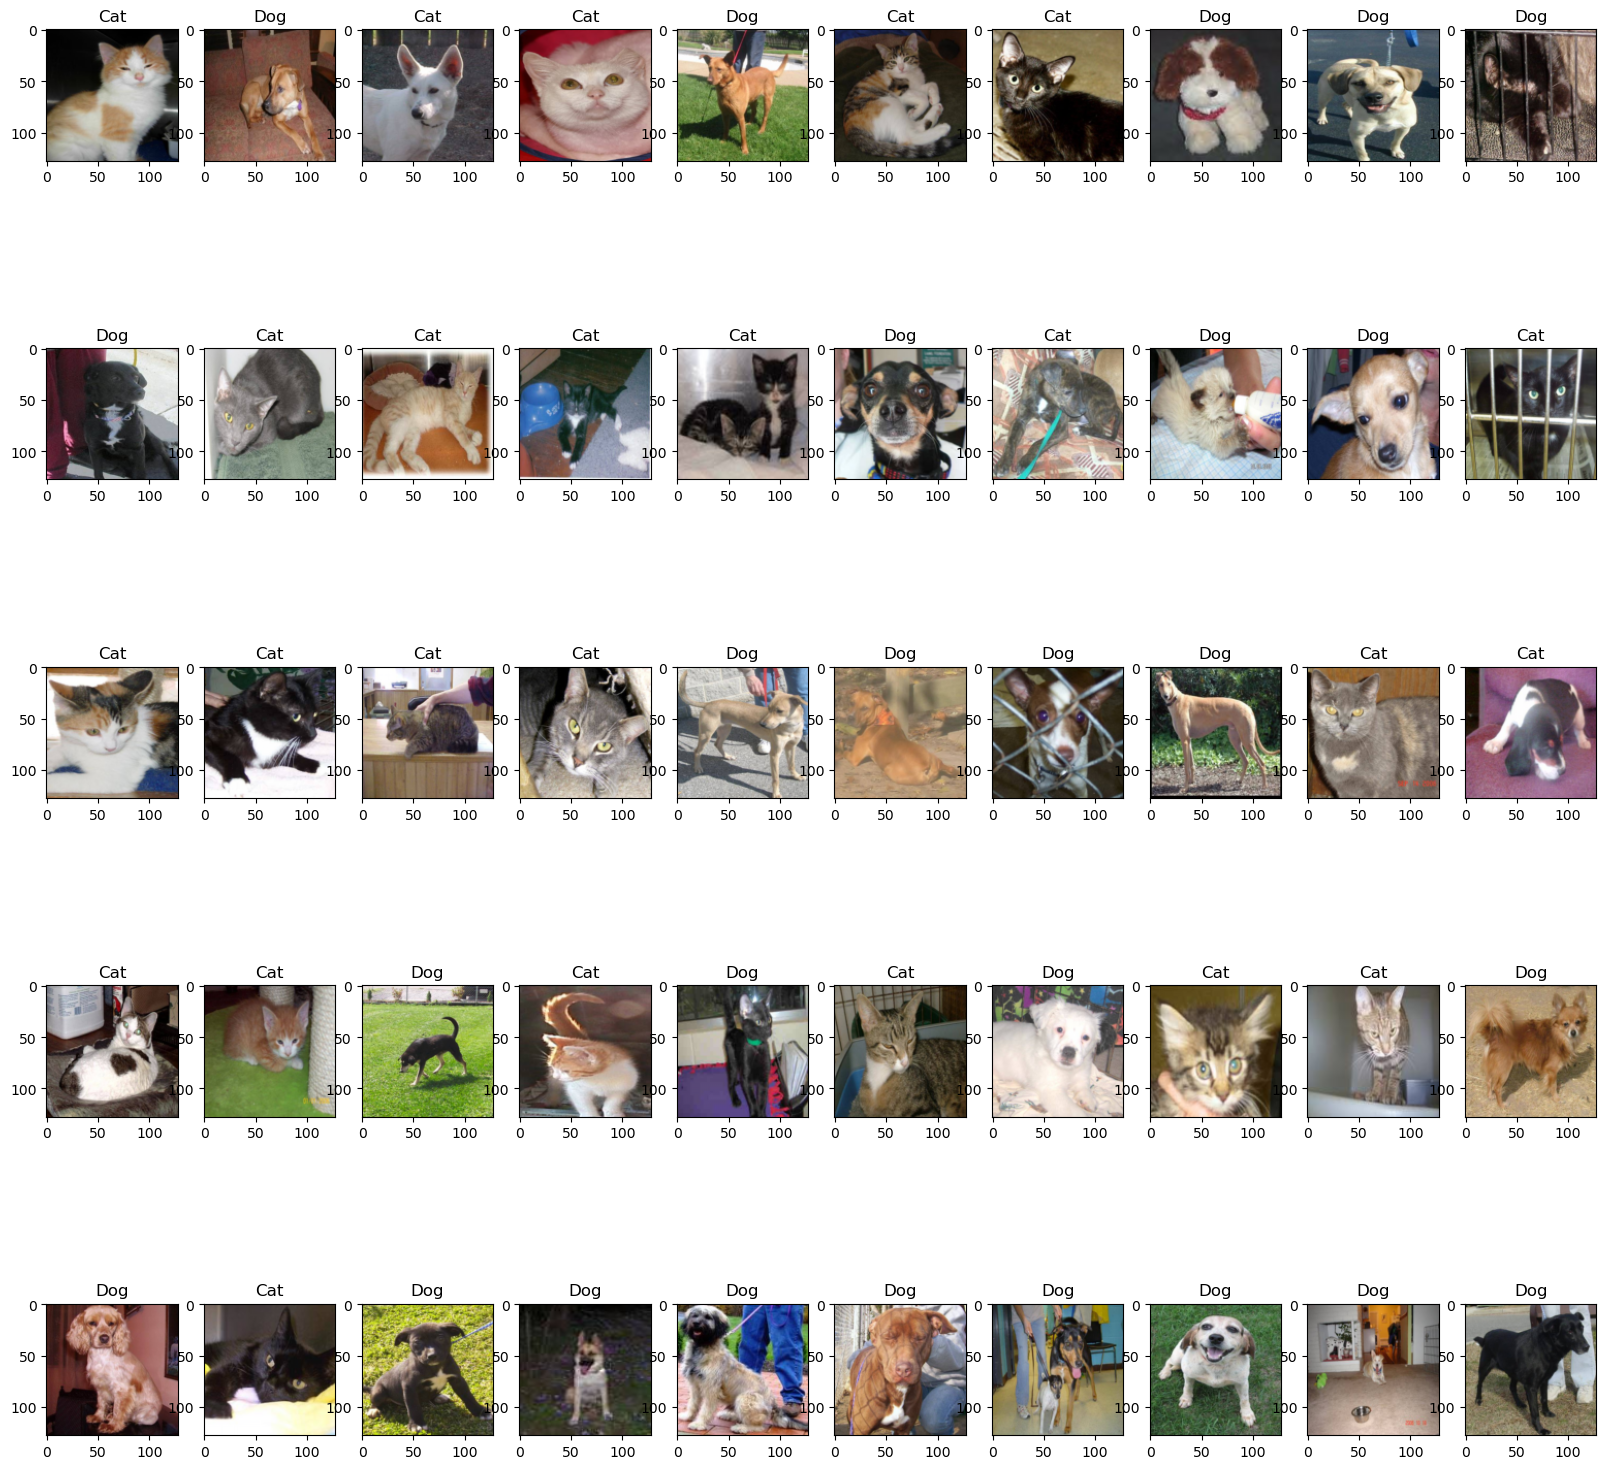

In [18]:
%matplotlib inline
import matplotlib.pyplot as plt
stop = 50
fig = plt.figure(figsize = (20, 20))
for i, image in enumerate(test_loader):
    Class = torch.argmax(ConvNet.forward(image), dim = 1)
    label = "Cat" if Class == 0 else "Dog"
    rows = stop//10
    columns = stop//rows
    ax = fig.add_subplot(rows, columns, i+1)
    # PyTorch uses (channels, width, height) for images, but matplotlib uses (width, height, channels). Use .permute to change it from PyTorch to Matplotlib format

    image_for_plotting = image.reshape(image.shape[1], image.shape[2], image.shape[3]).permute(1, 2, 0)
    ax.imshow(np.minimum(image_for_plotting*stds + means, 1.0))
    ax.set_title(label)
    

    if i == stop-1:
        break
plt.show()
    